In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from background_functions import read_audio_chunk

# paths and settings
DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")
n_hours = 72
fs_new = 1000

In [2]:
def plot_long_term_spectrogram(audio_file, n_hours, fs_new, nperseg=1024, bin_s=60.0,
                               fmax=None, stat="median"):
    """
    Long-term spectrogram: each hour is read, spectrogrammed, and collapsed into
    bin_s-second bins. stat="median" shows background noise (calls barely move it);
    stat="mean" is pulled up by loud transient calls too.
    """
    agg_fn = np.median if stat == "median" else np.mean
    cols = []
    for i in range(n_hours):
        f_s, audio = read_audio_chunk(audio_file, start_hour=i, duration_hour=1.0, fs_new=fs_new)
        f, t, Sxx = signal.spectrogram(audio, fs=f_s, nperseg=nperseg, noverlap=0, window="hamming")
        frames_per_bin = max(1, int(bin_s / (nperseg / f_s)))
        n_bins = Sxx.shape[1] // frames_per_bin
        Sxx = Sxx[:, :n_bins * frames_per_bin].reshape(len(f), n_bins, frames_per_bin)
        cols.append(agg_fn(Sxx, axis=2))
        print(f"Spectrogram hour {i+1} of {n_hours}")

    S_db = 10 * np.log10(np.concatenate(cols, axis=1) + 1e-12)   # (n_freq, n_time_bins)
    t_hours = np.arange(S_db.shape[1]) * bin_s / 3600.0

    if fmax is not None:
        keep = f <= fmax
        f, S_db = f[keep], S_db[keep]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})
    vmin, vmax = np.percentile(S_db, [2, 98])
    img = ax1.pcolormesh(t_hours, f, S_db, shading="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    ax1.set_ylabel("Freq (Hz)")
    ax1.set_title(f"Long-term spectrogram ({stat} per {bin_s:.0f} s)")
    fig.colorbar(img, ax=[ax1, ax2], label="Power (dB)")

    ax2.plot(t_hours, S_db.mean(axis=0), linewidth=0.8)
    ax2.set_ylabel("Mean level (dB)")
    ax2.set_xlabel("Time (hours)")
    ax2.grid(alpha=0.3)
    plt.show()
    return t_hours, S_db, f

Spectrogram hour 1 of 72
Spectrogram hour 2 of 72
Spectrogram hour 3 of 72
Spectrogram hour 4 of 72
Spectrogram hour 5 of 72
Spectrogram hour 6 of 72
Spectrogram hour 7 of 72
Spectrogram hour 8 of 72
Spectrogram hour 9 of 72
Spectrogram hour 10 of 72
Spectrogram hour 11 of 72
Spectrogram hour 12 of 72
Spectrogram hour 13 of 72
Spectrogram hour 14 of 72
Spectrogram hour 15 of 72
Spectrogram hour 16 of 72
Spectrogram hour 17 of 72
Spectrogram hour 18 of 72
Spectrogram hour 19 of 72
Spectrogram hour 20 of 72
Spectrogram hour 21 of 72
Spectrogram hour 22 of 72
Spectrogram hour 23 of 72
Spectrogram hour 24 of 72
Spectrogram hour 25 of 72
Spectrogram hour 26 of 72
Spectrogram hour 27 of 72
Spectrogram hour 28 of 72
Spectrogram hour 29 of 72
Spectrogram hour 30 of 72
Spectrogram hour 31 of 72
Spectrogram hour 32 of 72
Spectrogram hour 33 of 72
Spectrogram hour 34 of 72
Spectrogram hour 35 of 72
Spectrogram hour 36 of 72
Spectrogram hour 37 of 72
Spectrogram hour 38 of 72
Spectrogram hour 39 o

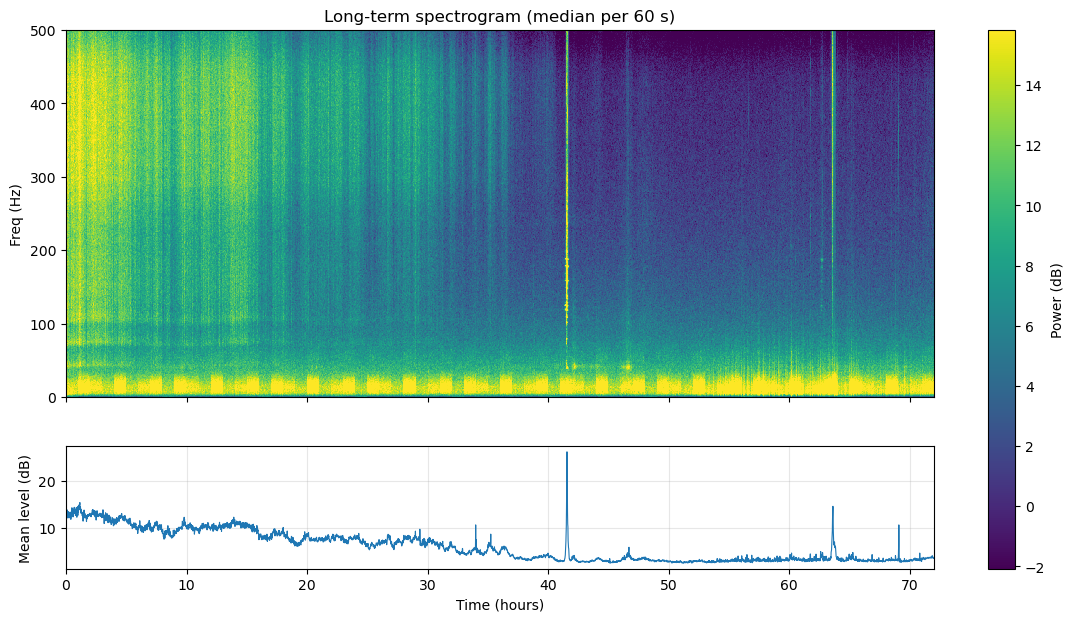

(array([0.00000000e+00, 1.66666667e-02, 3.33333333e-02, ...,
        7.19500000e+01, 7.19666667e+01, 7.19833333e+01], shape=(4320,)),
 array([[ 6.02644449,  7.33619313,  5.99647195, ..., -4.03362171,
         -2.94429447, -4.63723846],
        [ 8.51544555,  8.13779495,  8.64782728, ...,  3.35235436,
          4.8080082 ,  1.91821682],
        [13.48125033, 10.76591457, 10.85790179, ...,  8.35716355,
         10.11630737,  8.6730706 ],
        ...,
        [ 7.6270579 , 11.78438689,  9.751484  , ..., -0.79987237,
         -4.2342859 , -0.68650803],
        [ 8.16462067,  9.81870168, 10.5190374 , ..., -2.14893831,
         -2.8467331 , -1.11859136],
        [ 3.85657261,  3.11711112,  5.61912163, ..., -6.64523737,
         -5.60884437, -6.97942118]], shape=(513, 4320)),
 array([  0.       ,   0.9765625,   1.953125 ,   2.9296875,   3.90625  ,
          4.8828125,   5.859375 ,   6.8359375,   7.8125   ,   8.7890625,
          9.765625 ,  10.7421875,  11.71875  ,  12.6953125,  13.671875 ,
 

In [3]:
plot_long_term_spectrogram(
    DATA_22 / "20230422_171301.wav",
    n_hours=n_hours,
    fs_new=fs_new,
    fmax=500,        # optional: zoom into the band your calls live in
)